# Penetration vs. latitude

In [2]:
# loads in some modules used
import h5py
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd
import statistics

In [3]:
# parameters used for the simulation
r_tot = 70774597466.3827
r_bot = 0.4 * r_tot
r_top = 0.9 * r_tot
Nr = 504
Ntheta = 360
Nphi = 720
dr_grid = (r_top - r_bot) / Nr
r_env_init = 5.149819426617924E+10

In [3]:
# finds the files in post_checkpoint dir
PATTERN= "post_checkpoints/Om5/*"
all_files = sorted(glob.glob(PATTERN))

In [12]:
# this reads in the file, and constructs the pandas df
def read_file(fname):
    hf = h5py.File(fname)['Contours']
    df = pd.DataFrame(hf.get('glob_Schw_radius_envelope')[:,:,0])
    df['num_phi'] = df.index
    df = pd.melt(df, id_vars=['num_phi'], var_name='num_theta', value_name='glob_Schw')
    df['num_theta'] = df['num_theta'].astype(int)
    # df = df.set_index(['num_theta']).sort_index()
    df['conv_env'] = hf.get('pen_depth_conv_envelope')[:,:,0].T.flatten()
    df['glob_conv_env'] = hf.get('pen_depth_conv_glob_envelope')[:,:,0].T.flatten()
    df['enth_env'] = hf.get('pen_depth_enth_envelope')[:,:,0].T.flatten()
    df['glob_enth_env'] = hf.get('pen_depth_enth_glob_envelope')[:,:,0].T.flatten()
    df['vel_env'] = hf.get('pen_depth_vel_envelope')[:,:,0].T.flatten()
    df['glob_vel_env'] = hf.get('pen_depth_vel_glob_envelope')[:,:,0].T.flatten()
    df["checkpoint"] = int(fname[-9:-3]) # simply takes the checkpoint number from file name
    return df

In [5]:
all_files = all_files[-200:]

In [6]:
all_data = None
print('loading files from {} to {}'.format(all_files[0], all_files[-1]))
all_data = pd.concat([read_file(f) for f in all_files], ignore_index=True)
print('loaded files')

loading files from post_checkpoints/Om5\h5file_post_1dmom.003500.h5 to post_checkpoints/Om5\h5file_post_1dmom.003599.h5
loaded files


In [7]:

all_data = all_data.set_index(["num_theta"]).sort_index()

In [8]:
all_data

,num_phi,glob_Schw,conv_env,glob_conv_env,enth_env,glob_enth_env,vel_env,glob_vel_env,checkpoint
num_theta,,,,,,,,,
0,0,5.313010e+10,5.305988e+10,5.270882e+10,5.305988e+10,5.270882e+10,5.305988e+10,5.270882e+10,3500
0,8,5.320031e+10,5.313010e+10,5.277903e+10,5.313010e+10,5.277903e+10,5.313010e+10,5.277903e+10,3580
0,7,5.530670e+10,5.516627e+10,5.277903e+10,5.516627e+10,5.277903e+10,5.516627e+10,5.277903e+10,3580
0,6,5.530670e+10,5.523648e+10,5.277903e+10,5.523648e+10,5.277903e+10,5.523648e+10,5.277903e+10,3580
0,5,5.530670e+10,5.523648e+10,5.277903e+10,5.523648e+10,5.277903e+10,5.523648e+10,5.277903e+10,3580
...,...,...,...,...,...,...,...,...,...
359,1,5.305988e+10,5.270882e+10,5.270882e+10,5.270882e+10,5.270882e+10,5.270882e+10,5.270882e+10,3566
359,2,5.305988e+10,5.270882e+10,5.270882e+10,5.270882e+10,5.270882e+10,5.270882e+10,5.270882e+10,3566
359,3,5.305988e+10,5.270882e+10,5.270882e+10,5.270882e+10,5.270882e+10,5.270882e+10,5.270882e+10,3566


In [8]:

# all_data['depth'] = (all_data['glob_Schw'] - all_data['vel_env']) / r_tot
all_data['depth'] = (all_data['glob_Schw'] - all_data['vel_env']) / r_tot
df_combined = all_data.groupby(all_data.index).mean()

In [9]:

theta_low = 30
theta_high = 150
df_combined['theta_deg'] = theta_low + (theta_high - theta_low) * df_combined.index / (Ntheta - 1)

In [10]:
df_combined

,num_phi,glob_Schw,conv_env,glob_conv_env,enth_env,glob_enth_env,vel_env,glob_vel_env,checkpoint,depth,theta_deg
num_theta,,,,,,,,,,,
0,359.5,5.421915e+10,5.397437e+10,5.266743e+10,5.397437e+10,5.266743e+10,5.395447e+10,5.266668e+10,3549.5,0.003740,30.000000
1,359.5,5.454802e+10,5.416216e+10,5.261025e+10,5.416216e+10,5.261025e+10,5.413041e+10,5.260997e+10,3549.5,0.005900,30.334262
2,359.5,5.468878e+10,5.427481e+10,5.256225e+10,5.427481e+10,5.256225e+10,5.415487e+10,5.256225e+10,3549.5,0.007544,30.668524
3,359.5,5.468638e+10,5.431079e+10,5.255281e+10,5.431079e+10,5.255281e+10,5.409442e+10,5.255281e+10,3549.5,0.008364,31.002786
4,359.5,5.456079e+10,5.424152e+10,5.255284e+10,5.424152e+10,5.255284e+10,5.394550e+10,5.255189e+10,3549.5,0.008694,31.337047
...,...,...,...,...,...,...,...,...,...,...,...
355,359.5,5.507116e+10,5.452472e+10,5.255510e+10,5.452472e+10,5.255510e+10,5.442592e+10,5.255095e+10,3549.5,0.009117,148.662953
356,359.5,5.489863e+10,5.438660e+10,5.259573e+10,5.438660e+10,5.259573e+10,5.435336e+10,5.259172e+10,3549.5,0.007704,148.997214
357,359.5,5.473330e+10,5.439039e+10,5.264203e+10,5.439039e+10,5.264203e+10,5.437559e+10,5.264072e+10,3549.5,0.005054,149.331476


In [11]:
mean = np.mean(df_combined['depth'])
mean

0.005755736783203365

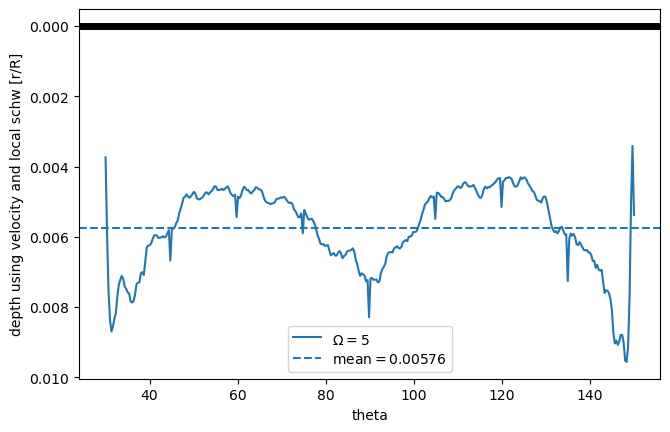

In [12]:
fig, ax = plt.subplots(figsize=(7.5,4.8))
fig.gca().invert_yaxis()
ax.axhline(y=0,color='k',linewidth=5)
ax.plot(df_combined['theta_deg'], df_combined['depth'], color='tab:blue', label=r'$\Omega_{}=5$')

ax.axhline(y=mean,color='tab:blue',linestyle='--', label='mean$=${:.5f}'.format(mean))

ax.set_xlabel('theta')
ax.set_ylabel('depth using velocity and local schw [r/R]')
ax.legend()
# fig.savefig('depth vs. theta.png')

In [13]:
n = 8

# Get indices of N largest elements
indices = np.argpartition(df_combined['depth'], -n)[-n:]
# Sort these indices by value in descending order
indices = indices[np.argsort(-df_combined['depth'][indices])]

print("Indices:", indices) # [6 3 4]
print("Values:", df_combined['depth'][indices]) # [9 5 4]

Indices: [354 353 355 348 346 352 349 347]
Values: num_theta
354    0.009560
353    0.009523
355    0.009117
348    0.009073
346    0.009035
352    0.009023
349    0.008971
347    0.008952
Name: depth, dtype: float64


In [14]:
indices.sort()
indices
indices_deg = theta_low + (theta_high - theta_low) * indices / (Ntheta - 1)
indices_deg

array([145.6545961 , 145.98885794, 146.32311978, 146.65738162,
       147.66016713, 147.99442897, 148.32869081, 148.66295265])

In [15]:
indices

array([346, 347, 348, 349, 352, 353, 354, 355], dtype=int64)

In [16]:
59.74930362 - 44.70752089

15.041782730000001

In [17]:
((df_combined['depth'][indices] - mean).values) * r_tot / dr_grid

array([3.30546732, 3.22232843, 3.34413399, 3.24110621, 3.29377288,
       3.79745343, 3.83423121, 3.38805066])

In [18]:
# 1.11083256, 1.09833256, 1.06749923, 0.98249923, 0.90888812,
#        0.85499923, 0.83583256, 0.60583256
# 2.85287423, 1.91120756, 2.34426312, 1.79926312, 1.81759645,
#        1.80231867, 3.15370756, 1.89815201

## Omega 1

In [19]:
# finds the files in post_checkpoint dir
PATTERN= "post_checkpoints/Om1/*"
all_files = sorted(glob.glob(PATTERN))

In [20]:
all_files = all_files[-200:]

In [21]:
all_data = None
print('loading files from {} to {}'.format(all_files[0], all_files[-1]))
all_data = pd.concat([read_file(f) for f in all_files], ignore_index=True)
print('loaded files')

loading files from post_checkpoints/Om1\h5file_post_1dmom.003400.h5 to post_checkpoints/Om1\h5file_post_1dmom.003599.h5
loaded files


In [22]:

all_data = all_data.set_index(["num_theta"]).sort_index()

In [23]:

all_data['depth'] = (all_data['glob_Schw'] - all_data['vel_env']) / r_tot
df_combined = all_data.groupby(all_data.index).mean()

In [24]:

theta_low = 30
theta_high = 150
df_combined['theta_deg'] = theta_low + (theta_high - theta_low) * df_combined.index / (Ntheta - 1)

In [25]:
mean = np.mean(df_combined['depth'])
mean

0.00795725019672844

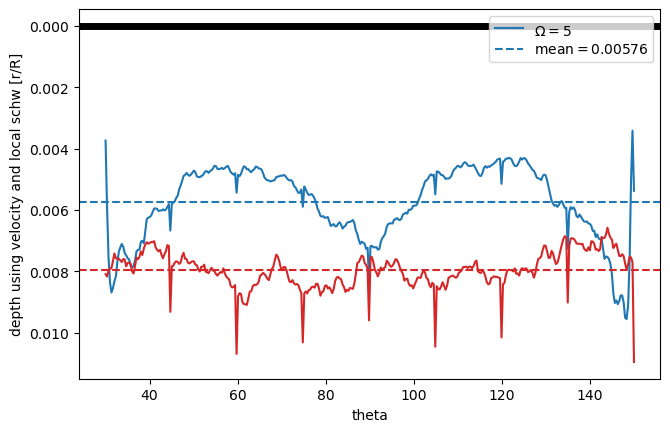

In [26]:
ax.plot(df_combined['theta_deg'], df_combined['depth'], color='tab:red', label=r'$\Omega_{}=1$')

ax.axhline(y=mean,color='tab:red',linestyle='--', label='mean$=${:.5f}'.format(mean))

# ax.legend()
# fig.savefig('depth vs. theta.png')
fig

## Omega 0

In [27]:
# finds the files in post_checkpoint dir
PATTERN= "post_checkpoints/Om0/*"
all_files = sorted(glob.glob(PATTERN))

In [28]:
all_files = all_files[-200:]

In [29]:
all_data = None
print('loading files from {} to {}'.format(all_files[0], all_files[-1]))
all_data = pd.concat([read_file(f) for f in all_files], ignore_index=True)
print('loaded files')

loading files from post_checkpoints/Om0\h5file_post_1dmom.003397.h5 to post_checkpoints/Om0\h5file_post_1dmom.003596.h5
loaded files


In [30]:

all_data = all_data.set_index(["num_theta"]).sort_index()

In [31]:

all_data['depth'] = (all_data['glob_Schw'] - all_data['vel_env']) / r_tot
df_combined = all_data.groupby(all_data.index).mean()

In [32]:

theta_low = 30
theta_high = 150
df_combined['theta_deg'] = theta_low + (theta_high - theta_low) * df_combined.index / (Ntheta - 1)

In [33]:
mean = np.mean(df_combined['depth'])
mean

0.008562875200555832

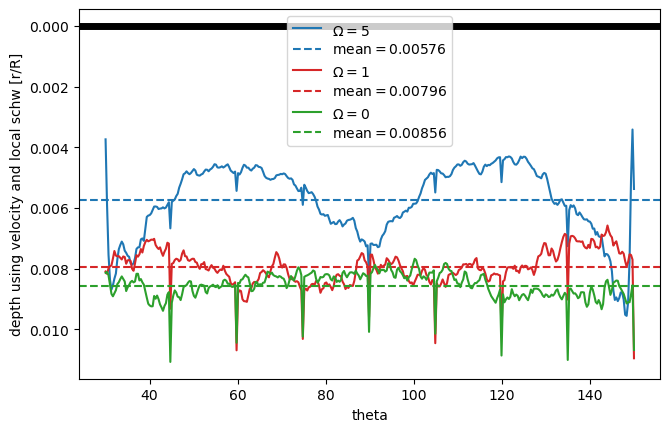

In [34]:
ax.plot(df_combined['theta_deg'], df_combined['depth'], color='tab:green', label=r'$\Omega_{}=0$')

ax.axhline(y=mean,color='tab:green',linestyle='--', label='mean$=${:.5f}'.format(mean))
ax.legend()
# fig.savefig('depth vs. theta.png')
fig

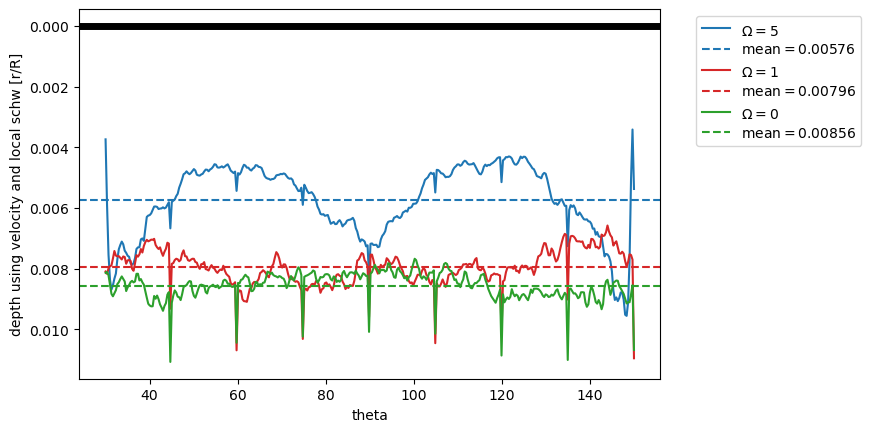

In [35]:
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
fig

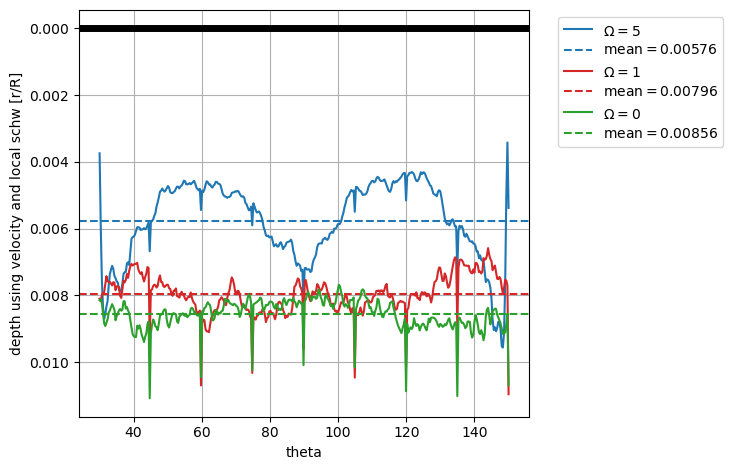

In [36]:
ax.grid()
fig.tight_layout()
fig.savefig('init_Schw_depth_vs_theta.png')
fig

### Checking evolution of Schw

In [37]:
# finds the files in post_checkpoint dir
PATTERN= "post_checkpoints/Om0/*"
all_files = sorted(glob.glob(PATTERN))

In [38]:
all_files = all_files[0]
all_data = None
all_data = read_file(all_files)

In [39]:

all_data = all_data.set_index(["num_theta"]).sort_index()

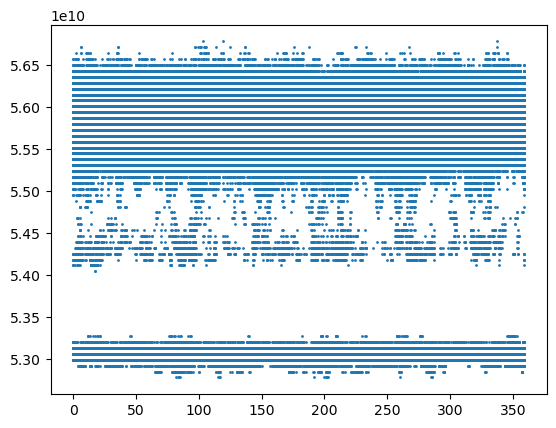

In [40]:
plt.scatter(all_data.index, all_data['glob_Schw'],s=1)

In [41]:
Schw_start = all_data['glob_Schw'].mean()
Schw_start

55485882756.23486

In [42]:
# finds the files in post_checkpoint dir
PATTERN= "post_checkpoints/Om0/*"
all_files = sorted(glob.glob(PATTERN))

In [43]:
all_files = all_files[-1]
all_data = None
all_data = read_file(all_files)

In [44]:

all_data = all_data.set_index(["num_theta"]).sort_index()

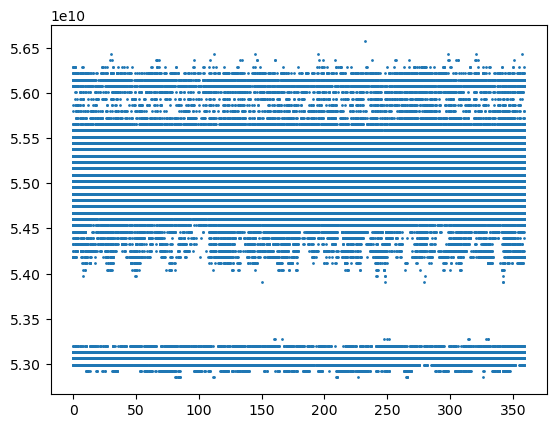

In [45]:
plt.scatter(all_data.index, all_data['glob_Schw'],s=1)

In [46]:
Schw_end = all_data['glob_Schw'].mean()
Schw_end

54895058316.234375

In [47]:
(Schw_end - Schw_start) / r_tot

-0.008347973159170909

In [48]:
Schw_end / r_tot

0.7756322223140729

In [49]:
Schw_start / r_tot

0.7839801954732438

In [50]:
# finds the files in post_checkpoint dir
PATTERN= "post_checkpoints/Om0/*"
all_files = sorted(glob.glob(PATTERN))

In [51]:
all_data = None
print('loading files from {} to {}'.format(all_files[0], all_files[-1]))
all_data = pd.concat([read_file(f) for f in all_files], ignore_index=True)
print('loaded files')

loading files from post_checkpoints/Om0\h5file_post_1dmom.002000.h5 to post_checkpoints/Om0\h5file_post_1dmom.003596.h5
loaded files


In [52]:

all_data = all_data.set_index(["checkpoint"]).sort_index()

In [53]:
df_combined = all_data.groupby(all_data.index).mean()
df_combined

,num_phi,num_theta,glob_Schw,conv_env,glob_conv_env,enth_env,glob_enth_env,vel_env,glob_vel_env
checkpoint,,,,,,,,,
2000,359.5,179.5,5.548588e+10,5.523920e+10,5.529451e+10,5.523920e+10,5.529451e+10,5.490697e+10,5.492928e+10
2002,359.5,179.5,5.548531e+10,5.523872e+10,5.529532e+10,5.523872e+10,5.529532e+10,5.490629e+10,5.493030e+10
2004,359.5,179.5,5.548354e+10,5.523689e+10,5.529509e+10,5.523689e+10,5.529509e+10,5.490345e+10,5.492909e+10
2006,359.5,179.5,5.548218e+10,5.523572e+10,5.529491e+10,5.523572e+10,5.529491e+10,5.489977e+10,5.492658e+10
2008,359.5,179.5,5.548052e+10,5.523401e+10,5.529445e+10,5.523401e+10,5.529445e+10,5.489757e+10,5.492518e+10
...,...,...,...,...,...,...,...,...,...
3592,359.5,179.5,5.489563e+10,5.466632e+10,5.473431e+10,5.466632e+10,5.473431e+10,5.428420e+10,5.433206e+10
3593,359.5,179.5,5.489614e+10,5.466684e+10,5.473423e+10,5.466684e+10,5.473423e+10,5.428514e+10,5.433199e+10
3594,359.5,179.5,5.489580e+10,5.466637e+10,5.473401e+10,5.466637e+10,5.473401e+10,5.428526e+10,5.433377e+10


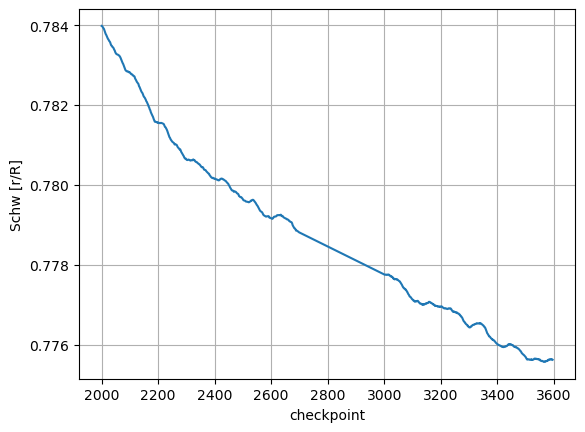

In [54]:
fig2, ax2 = plt.subplots()
ax2.plot(df_combined.index, df_combined['glob_Schw'] / r_tot)

ax2.grid()
ax2.set_xlabel('checkpoint')
ax2.set_ylabel('Schw [r/R]')
fig2.savefig('Schw_Om0_vs_checkpoint.png')

In [9]:
# finds the files in post_checkpoint dir
PATTERN= "post_checkpoints/Om0/*2000*"
all_files = sorted(glob.glob(PATTERN))

In [10]:
all_files

['post_checkpoints/Om0\\h5file_post_1dmom.002000.h5']

In [13]:
all_data = pd.concat([read_file(f) for f in all_files], ignore_index=True)

In [23]:
theta_low = 30
theta_high = 150
all_data['theta_deg'] = theta_low + (theta_high - theta_low) * all_data['num_theta'].values / (Ntheta - 1)

In [24]:
all_data

,num_phi,num_theta,glob_Schw,conv_env,glob_conv_env,enth_env,glob_enth_env,vel_env,glob_vel_env,checkpoint,theta_deg
0,0,0,5.425350e+10,5.411308e+10,5.523648e+10,5.411308e+10,5.523648e+10,5.383223e+10,5.509606e+10,2000,30.0
1,1,0,5.418329e+10,5.411308e+10,5.544712e+10,5.411308e+10,5.544712e+10,5.362159e+10,5.516627e+10,2000,30.0
2,2,0,5.418329e+10,5.411308e+10,5.544712e+10,5.411308e+10,5.544712e+10,5.348116e+10,5.523648e+10,2000,30.0
3,3,0,5.418329e+10,5.411308e+10,5.544712e+10,5.411308e+10,5.544712e+10,5.348116e+10,5.544712e+10,2000,30.0
4,4,0,5.411308e+10,5.341095e+10,5.544712e+10,5.341095e+10,5.544712e+10,5.341095e+10,5.544712e+10,2000,30.0
...,...,...,...,...,...,...,...,...,...,...,...
259195,715,359,5.621946e+10,5.558755e+10,5.516627e+10,5.558755e+10,5.516627e+10,5.516627e+10,5.516627e+10,2000,150.0
259196,716,359,5.621946e+10,5.558755e+10,5.544712e+10,5.558755e+10,5.544712e+10,5.544712e+10,5.544712e+10,2000,150.0
259197,717,359,5.621946e+10,5.565776e+10,5.544712e+10,5.565776e+10,5.544712e+10,5.544712e+10,5.544712e+10,2000,150.0
259198,718,359,5.593861e+10,5.565776e+10,5.544712e+10,5.565776e+10,5.544712e+10,5.544712e+10,5.544712e+10,2000,150.0


In [25]:
df = all_data[all_data['num_phi']==0]

In [26]:
df

,num_phi,num_theta,glob_Schw,conv_env,glob_conv_env,enth_env,glob_enth_env,vel_env,glob_vel_env,checkpoint,theta_deg
0,0,0,5.425350e+10,5.411308e+10,5.523648e+10,5.411308e+10,5.523648e+10,5.383223e+10,5.509606e+10,2000,30.000000
720,0,1,5.425350e+10,5.418329e+10,5.544712e+10,5.418329e+10,5.544712e+10,5.362159e+10,5.502585e+10,2000,30.334262
1440,0,2,5.432372e+10,5.425350e+10,5.537691e+10,5.425350e+10,5.537691e+10,5.305988e+10,5.305988e+10,2000,30.668524
2160,0,3,5.565776e+10,5.516627e+10,5.516627e+10,5.516627e+10,5.516627e+10,5.298967e+10,5.298967e+10,2000,31.002786
2880,0,4,5.558755e+10,5.516627e+10,5.516627e+10,5.516627e+10,5.516627e+10,5.418329e+10,5.418329e+10,2000,31.337047
...,...,...,...,...,...,...,...,...,...,...,...
255600,0,355,5.607904e+10,5.600883e+10,5.544712e+10,5.600883e+10,5.544712e+10,5.600883e+10,5.544712e+10,2000,148.662953
256320,0,356,5.544712e+10,5.537691e+10,5.544712e+10,5.537691e+10,5.544712e+10,5.474499e+10,5.544712e+10,2000,148.997214
257040,0,357,5.586840e+10,5.579819e+10,5.544712e+10,5.579819e+10,5.544712e+10,5.579819e+10,5.544712e+10,2000,149.331476
257760,0,358,5.579819e+10,5.572797e+10,5.544712e+10,5.572797e+10,5.544712e+10,5.572797e+10,5.544712e+10,2000,149.665738


In [30]:
theta = df['theta_deg'].values
depth = df['theta_deg'].values